# WTI MM Long — Daily COT Nowcasting with dynamax

**Key insight**: COT is as-of Tuesday but released Friday. The KF should
estimate **Tuesday's** positioning and get corrected on Friday.

## Augmented state: `[α_current, α_tuesday]`

- `α_current` evolves daily with market features
- `α_tuesday` snapshots `α_current` after Tuesday, freezes until next Tuesday
- Friday observation corrects `α_tuesday`, not `α_current`

## Two-stage fitting

1. Fit `B`, `Q`, `R` on a simple (non-augmented) model using **EM**
2. Plug learned params into the augmented model for **filtering only**

(EM can't handle time-varying transition matrices, so we separate learning from structure.)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import numpy as np
import jax.numpy as jnp
import jax.random as jr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from dynamax.linear_gaussian_ssm import LinearGaussianSSM
from dynamax.linear_gaussian_ssm.inference import (
    ParamsLGSSM, ParamsLGSSMInitial, ParamsLGSSMDynamics, ParamsLGSSMEmissions,
)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load and prepare

In [2]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)
df = pdr.read_daily_dataset(ticker=FutureTicker.WTI)
df['tradeDate'] = pd.to_datetime(df['tradeDate'])
df.sort_values('tradeDate', inplace=True)
df.reset_index(drop=True, inplace=True)

TARGET = 'cot_obs_ManagedMoney_LongPosition'
FEATURES = [
    'F1_RolledPrice_daily_return', 'F1MinusF2_RolledPrice_daily_return',
    'F1_RolledPrice_rolling_20D_volatility', 'F1_OI_daily_change',
    'AGG_OI_daily_change', 'F1_Volume', 'SyntheticSpread_daily_change',
]
df = df[df[FEATURES].notna().all(axis=1)].reset_index(drop=True)

dates = df['tradeDate'].values
dow = pd.to_datetime(dates).dayofweek.values
y_raw = df[TARGET].values.astype(float)
X_raw = df[FEATURES].values.astype(float)
obs_mask = ~np.isnan(y_raw)
p = len(FEATURES)

TRAIN_END, TEST_END = '2014-12-31', '2017-12-31'
train_idx = np.where(df['tradeDate'] <= TRAIN_END)[0]
full_idx  = np.where(df['tradeDate'] <= TEST_END)[0]

# Standardise from train
X_mean = np.nanmean(X_raw[train_idx], axis=0)
X_std  = np.nanstd(X_raw[train_idx], axis=0) + 1e-8
X = (X_raw - X_mean) / X_std

y_train_obs = y_raw[train_idx][obs_mask[train_idx]]
y_mean = y_train_obs.mean()
y_std_ = y_train_obs.std() + 1e-8
y_scaled = (y_raw - y_mean) / y_std_

print(f'Train: {len(train_idx)} days, {obs_mask[train_idx].sum()} Fri obs')
print(f'Test:  {len(full_idx)-len(train_idx)} days, {obs_mask[full_idx[len(train_idx):]].sum()} Fri obs')

Train: 1236 days, 248 Fri obs
Test:  755 days, 151 Fri obs


## 2. Stage 1 — Learn B, Q, R with EM on simple model

In [3]:
simple = LinearGaussianSSM(state_dim=1, emission_dim=1, input_dim=p)
T_tr = len(train_idx)

# Replace NaN with 0, use huge R for missing obs
y_clean = np.where(np.isnan(y_scaled[train_idx]), 0.0, y_scaled[train_idx]).reshape(T_tr, 1)
R_tv = np.where(obs_mask[train_idx][:, None, None],
                np.eye(1)[None] * 1.0,
                np.eye(1)[None] * 1e10)

params_s, props_s = simple.initialize(jr.PRNGKey(42),
    initial_mean=jnp.array([0.0]), initial_covariance=jnp.eye(1),
    dynamics_weights=jnp.eye(1), dynamics_covariance=jnp.eye(1) * 0.01,
    dynamics_input_weights=jnp.zeros((1, p)),
    emission_weights=jnp.eye(1), emission_covariance=jnp.eye(1))

# Override emission cov with time-varying version
params_s = ParamsLGSSM(initial=params_s.initial, dynamics=params_s.dynamics,
    emissions=ParamsLGSSMEmissions(
        weights=params_s.emissions.weights, bias=params_s.emissions.bias,
        input_weights=params_s.emissions.input_weights, cov=jnp.array(R_tv)))

params_em, lls = simple.fit_em(params_s, props_s,
    emissions=jnp.array(y_clean), inputs=jnp.array(X[train_idx]),
    num_iters=100, verbose=False)

q_l = float(np.array(params_em.dynamics.cov).flatten()[0])
B_l = np.array(params_em.dynamics.input_weights).reshape(-1, p)[0]
r_l = float(np.array(params_em.emissions.cov).flatten()[0])

print(f'EM loglik: {float(lls[0]):.1f} -> {float(lls[-1]):.1f}')
print(f'Q (state noise) = {q_l:.6f}')
print(f'R (obs noise)   = {r_l:.6f}')
print(f'B (features):     {B_l.round(4)}')

EM loglik: -12548.5 -> -641.3
Q (state noise) = 0.005579
R (obs noise)   = 0.163962
B (features):     [ 0.0413 -0.0248 -0.0065 -0.0009  0.0331 -0.0133  0.0027]


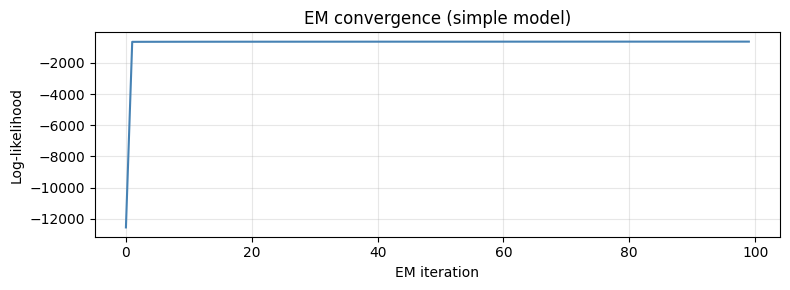

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.array(lls), color='steelblue')
ax.set_xlabel('EM iteration'); ax.set_ylabel('Log-likelihood')
ax.set_title('EM convergence (simple model)')
plt.tight_layout()
plt.show()

## 3. Stage 2 — Build augmented model and filter

In [5]:
T_full = len(full_idx)
sd, ed = 2, 1
dow_f = dow[full_idx]
obs_f = obs_mask[full_idx]
is_tue = (dow_f == 1)
is_fri = (dow_f == 4)

# F[t] transitions filtered[t] -> predicted[t+1]
# On Tuesday: snapshot α_current into α_tuesday
# Other days: freeze α_tuesday
F = np.zeros((T_full, sd, sd))
for t in range(T_full):
    F[t, 0, 0] = 1.0
    if is_tue[t]: F[t, 1, 0] = 1.0
    else:         F[t, 1, 1] = 1.0

B_aug = np.zeros((T_full, sd, p))
B_aug[:, 0, :] = B_l          # features drive α_current only

Q_aug = np.zeros((T_full, sd, sd))
Q_aug[:, 0, 0] = q_l          # noise on α_current only

H = np.zeros((T_full, ed, sd))
H[:, 0, 1] = 1.0              # observe α_tuesday

R_aug = np.zeros((T_full, ed, ed))
R_aug[:, 0, 0] = np.where(is_fri, r_l, 1e10)

y_fc = np.where(np.isnan(y_scaled[full_idx]), 0.0, y_scaled[full_idx]).reshape(T_full, ed)
X_f = X[full_idx]

aug = LinearGaussianSSM(state_dim=sd, emission_dim=ed, input_dim=p)
params_aug = ParamsLGSSM(
    initial=ParamsLGSSMInitial(mean=jnp.zeros(sd), cov=jnp.eye(sd)),
    dynamics=ParamsLGSSMDynamics(
        weights=jnp.array(F), bias=jnp.zeros((T_full, sd)),
        input_weights=jnp.array(B_aug), cov=jnp.array(Q_aug)),
    emissions=ParamsLGSSMEmissions(
        weights=jnp.array(H), bias=jnp.zeros((T_full, ed)),
        input_weights=jnp.zeros((T_full, ed, p)), cov=jnp.array(R_aug)),
)

result = aug.filter(params_aug, jnp.array(y_fc), inputs=jnp.array(X_f))
fm = np.array(result.filtered_means)  # (T, 2)

# Compute predicted_means manually (dynamax doesn't return them for TV models)
# predicted[t] = F[t-1] @ filtered[t-1] + B[t-1] @ x[t-1]
pm = np.zeros_like(fm)
for t in range(1, T_full):
    pm[t] = F[t-1] @ fm[t-1] + B_aug[t-1] @ X_f[t-1]

# Back-transform
alpha_current    = fm[:, 0] * y_std_ + y_mean
alpha_tue_filt   = fm[:, 1] * y_std_ + y_mean   # post-correction
alpha_tue_pred   = pm[:, 1] * y_std_ + y_mean   # pre-correction (fair nowcast)
alpha_tue_std    = np.sqrt(np.array(result.filtered_covariances[:, 1, 1])) * y_std_

dates_full = dates[full_idx]
y_full = y_raw[full_idx]

print(f'Filter done. alpha_current range: {alpha_current.min():,.0f} -> {alpha_current.max():,.0f}')

Filter done. alpha_current range: 260,669 -> 853,916


## 4. Visualise

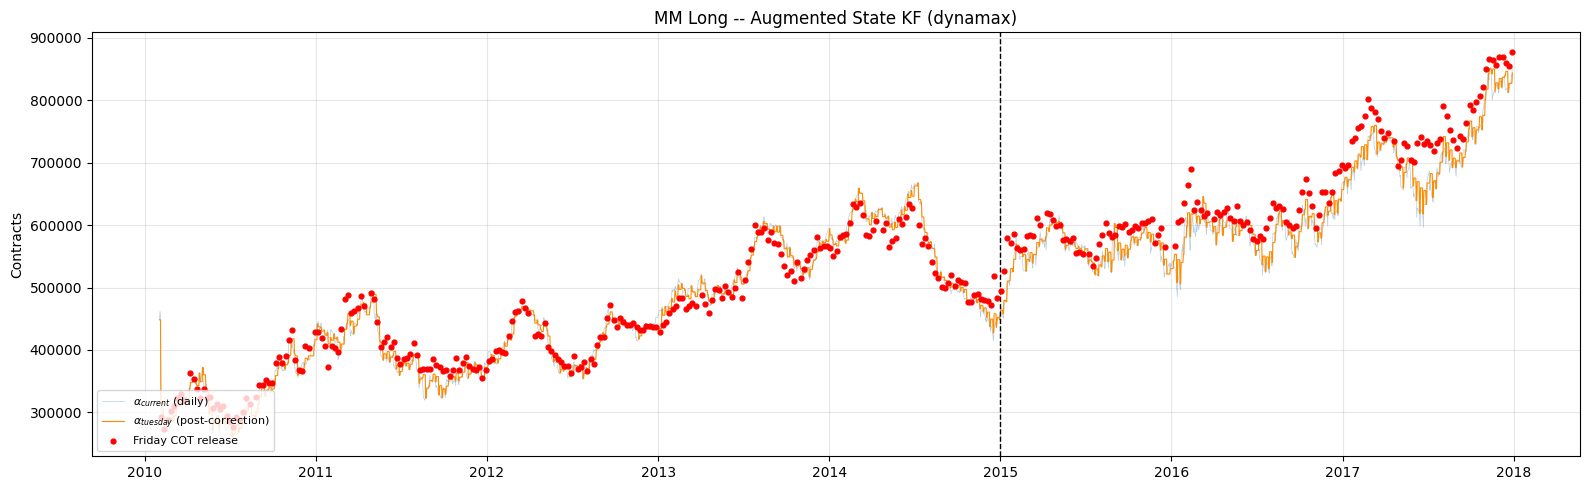

In [6]:
train_end_dt = np.datetime64(TRAIN_END)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_full, alpha_current, color='steelblue', linewidth=0.5,
        alpha=0.4, label='$\\alpha_{current}$ (daily)')
ax.plot(dates_full, alpha_tue_filt, color='darkorange', linewidth=0.8,
        label='$\\alpha_{tuesday}$ (post-correction)')
ax.scatter(dates_full[obs_f], y_full[obs_f],
           color='red', s=12, zorder=5, label='Friday COT release')
ax.axvline(train_end_dt, color='black', linestyle='--', linewidth=1)
ax.set_title('MM Long -- Augmented State KF (dynamax)')
ax.set_ylabel('Contracts')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

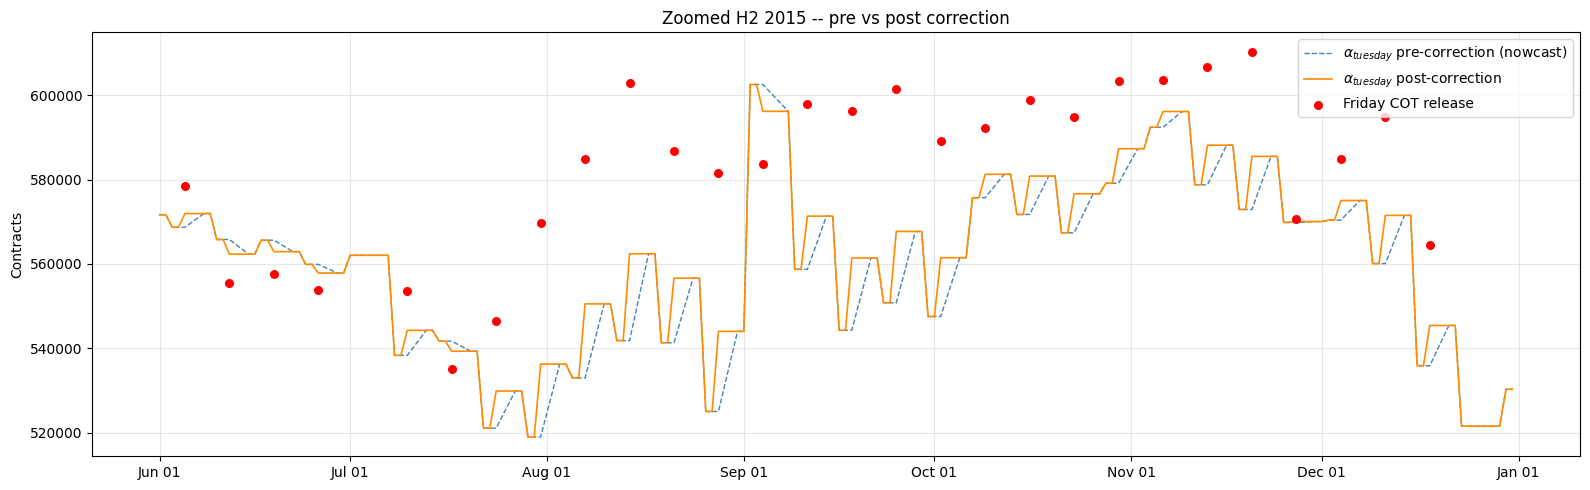

In [7]:
zoom_start = np.datetime64('2015-06-01')
zoom_end   = np.datetime64('2015-12-31')
zm = (dates_full >= zoom_start) & (dates_full <= zoom_end)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_full[zm], alpha_tue_pred[zm], color='steelblue',
        linewidth=1, linestyle='--', label='$\\alpha_{tuesday}$ pre-correction (nowcast)')
ax.plot(dates_full[zm], alpha_tue_filt[zm], color='darkorange',
        linewidth=1.2, label='$\\alpha_{tuesday}$ post-correction')
obs_zm = zm & obs_f
ax.scatter(dates_full[obs_zm], y_full[obs_zm],
           color='red', s=30, zorder=5, label='Friday COT release')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_title('Zoomed H2 2015 -- pre vs post correction')
ax.set_ylabel('Contracts')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Evaluation — weekly changes (pre-correction = fair)

On each Friday, the **pre-correction** α_tuesday is our true nowcast:
what we estimated for Tuesday's positioning before the CFTC report dropped.

In [8]:
test_start = len(train_idx)
test_fri = np.zeros(T_full, dtype=bool)
test_fri[test_start:] = obs_f[test_start:]
fri_idx = np.where(test_fri)[0]

pred_change   = np.diff(alpha_tue_pred[fri_idx])
filt_change   = np.diff(alpha_tue_filt[fri_idx])
actual_change = np.diff(y_full[fri_idx])

rho_fair, _   = stats.spearmanr(pred_change, actual_change)
dir_fair      = np.mean(np.sign(pred_change) == np.sign(actual_change))
rmse_fair     = np.sqrt(np.mean((pred_change - actual_change) ** 2))
rho_biased, _ = stats.spearmanr(filt_change, actual_change)

print(f'Test Fridays (changes): {len(pred_change)}')
print(f'\nPre-correction (FAIR -- true nowcast):')
print(f'  Spearman rho:  {rho_fair:.4f}')
print(f'  Dir. accuracy: {dir_fair:.1%}')
print(f'  RMSE:          {rmse_fair:,.0f} contracts')
print(f'\nPost-correction (BIASED -- uses Friday obs):')
print(f'  Spearman rho:  {rho_biased:.4f}')

Test Fridays (changes): 150

Pre-correction (FAIR -- true nowcast):
  Spearman rho:  0.1604
  Dir. accuracy: 62.0%
  RMSE:          26,854 contracts

Post-correction (BIASED -- uses Friday obs):
  Spearman rho:  0.4605


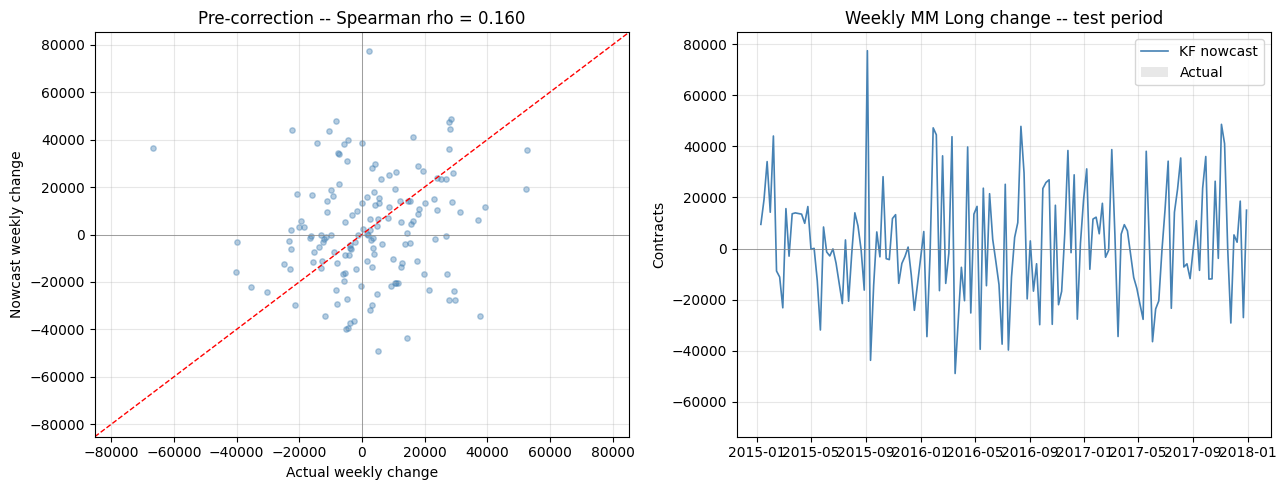

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(actual_change, pred_change, alpha=0.4, s=15, color='steelblue')
lim = max(np.abs(actual_change).max(), np.abs(pred_change).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('Actual weekly change')
ax.set_ylabel('Nowcast weekly change')
ax.set_title(f'Pre-correction -- Spearman rho = {rho_fair:.3f}')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)

ax = axes[1]
fri_dates = dates_full[fri_idx][1:]
ax.bar(fri_dates, actual_change, width=5, alpha=0.5, color='lightgrey', label='Actual')
ax.plot(fri_dates, pred_change, color='steelblue', linewidth=1.2, label='KF nowcast')
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Weekly MM Long change -- test period')
ax.set_ylabel('Contracts')
ax.legend()

plt.tight_layout()
plt.show()